# Feature engineering and selection

Run `02_preprocessing.ipynb` first. This notebook reads `promise_band_base.csv` and `order_seller_bridge.csv`. It does not rebuild the cohort, the label, or the split.

**Part 1** adds seller, customer, category, route, and marketplace history. An outcome enters a history feature only when its delivery timestamp is strictly before the purchase being scored. Volume features count earlier purchases even when those parcels have not arrived yet. Missing means "not yet observed". It does not mean "never late".

**Part 2** selects a feature set for the three-class promise band. The repository's `03_feature_engineering.ipynb` selects features for delivery-time regression. This notebook selects for the classification target, because that is the decision this table supports.

The selection rule is fixed before test is read:

1. On train, drop columns missing on more than 95% of rows, and constant columns.
2. On the remaining numeric columns, drop the weaker side of any pair with absolute Spearman correlation at least 0.92. Strength is mutual information with the binary late label, computed on a train sample. Median imputation in that sample is only for mutual information.
3. Fit a gradient-boosted tree on the surviving columns. Missing values stay missing. Class weight is balanced. The tree is a ranking instrument, not the final model.
4. On validation, permute each column and measure the drop in average precision of P(late). Five repeats. A column whose mean drop exceeds its standard deviation is a stable core. That flag is not the modelling set.
5. The modelling set is the shortest prefix of that ranking, on the grid 10, 16, 24, 36, and all surviving columns, whose validation late average precision is within 0.01 of the best prefix on the grid.

Accuracy is not the selection metric. Macro-F1, MCC, and quadratic weighted kappa are reported beside late average precision and late F1. Test is scored once, after the prefix is frozen, with the model fit on train only.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 140)

ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "data" / "processed" / "promise_band_base.csv").exists():
        ROOT = candidate
        break

OUT = ROOT / "data" / "processed"
FIG = ROOT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

BANDS = ["under_half", "half_to_full", "late"]
BAND_TO_CODE = {band: i for i, band in enumerate(BANDS)}
CAT_COLS = ["customer_state", "seller_state", "product_category", "purchase_dow", "purchase_month"]
CORR_THRESHOLD = 0.92
MI_SAMPLE = 15000
RANDOM_STATE = 42
AP_TOLERANCE = 0.01

base = pd.read_csv(
    OUT / "promise_band_base.csv",
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date"],
)
bridge = pd.read_csv(OUT / "order_seller_bridge.csv")
assert base["order_id"].is_unique
assert set(base["split"].unique()) == {"train", "val", "test", "excluded"}
df = base.copy()
print(f"base rows: {len(df):,}")
print(df["split"].value_counts().to_string())


base rows: 96,470
split
train       64429
test        14471
val         12541
excluded     5029


## Part 1. Feature table

### 1. Time-safe history

Seller outcome history counts every seller who had an item on a past order, because a multi-seller order has one delivery timestamp. `sellers_max_prior_late_rate` is the highest prior late rate among sellers on the current order. The 30-day late rate uses the primary seller only: deliveries of that seller with `event_time < purchase` and `event_time >= purchase - 30 days`. The order's own delivery is excluded by the left edge of the search.


In [3]:
def prior_count_in_window(frame, key, time_col, window_days, out_col):
    work = frame[[key, time_col]].copy()
    work["_i"] = np.arange(len(frame))
    work = work.sort_values([key, time_col, "_i"])
    counts = np.zeros(len(frame), dtype=np.int32)
    delta = np.timedelta64(int(window_days), "D")
    for _, group in work.groupby(key, sort=False):
        times = group[time_col].to_numpy()
        left = np.searchsorted(times, times - delta, side="left")
        right = np.searchsorted(times, times, side="left")
        counts[group["_i"].to_numpy()] = right - left
    frame[out_col] = counts
    return frame


def outcome_history_table(events, key):
    events = events.dropna(subset=["order_delivered_customer_date", key]).copy()
    events = events.sort_values(["order_delivered_customer_date", "order_id", key])
    grouped = events.groupby(key, sort=False)
    events["n"] = grouped.cumcount() + 1
    events["n_late"] = grouped["is_late"].cumsum()
    events["n_under"] = grouped["is_under_half"].cumsum()
    events["sum_ratio"] = grouped["duration_ratio"].cumsum()
    events["sum_actual"] = grouped["actual_days"].cumsum()
    events["late_rate"] = events["n_late"] / events["n"]
    events["under_half_rate"] = events["n_under"] / events["n"]
    events["mean_ratio"] = events["sum_ratio"] / events["n"]
    events["mean_actual_days"] = events["sum_actual"] / events["n"]
    keep = [
        key, "order_delivered_customer_date", "n",
        "late_rate", "under_half_rate", "mean_ratio", "mean_actual_days",
    ]
    return events[keep].rename(columns={"order_delivered_customer_date": "known_at"})


def asof_outcomes(left, history, key, prefix):
    renamed = history.rename(columns={
        "n": f"{prefix}_prior_delivered",
        "late_rate": f"{prefix}_prior_late_rate",
        "under_half_rate": f"{prefix}_prior_under_half_rate",
        "mean_ratio": f"{prefix}_prior_mean_ratio",
        "mean_actual_days": f"{prefix}_prior_mean_actual_days",
    })
    left_sorted = left.sort_values(["order_purchase_timestamp", "order_id"])
    right_sorted = renamed.sort_values(["known_at", key])
    merged = pd.merge_asof(
        left_sorted,
        right_sorted,
        left_on="order_purchase_timestamp",
        right_on="known_at",
        by=key,
        direction="backward",
        allow_exact_matches=False,
    )
    merged[f"{prefix}_prior_delivered"] = merged[f"{prefix}_prior_delivered"].fillna(0)
    return merged.drop(columns=["known_at"])


def prior_late_rate_in_window(frame, events, key, window_days=30):
    """Late rate of deliveries in [purchase - window, purchase). NaN when the count is zero."""
    ev = (
        events.dropna(subset=["order_delivered_customer_date", key, "is_late"])
        .sort_values(["order_delivered_customer_date", "order_id"])
    )
    n_out = np.zeros(len(frame), dtype=np.int32)
    rate_out = np.full(len(frame), np.nan)
    work = frame[[key, "order_purchase_timestamp"]].copy()
    work["_i"] = np.arange(len(frame))
    delta = np.timedelta64(int(window_days), "D")
    groups = {seller: group for seller, group in ev.groupby(key, sort=False)}
    for seller, group in work.groupby(key, sort=False):
        hist = groups.get(seller)
        if hist is None:
            continue
        times = hist["order_delivered_customer_date"].to_numpy()
        cumulative = np.cumsum(hist["is_late"].to_numpy(dtype=float))
        purchases = group["order_purchase_timestamp"].to_numpy()
        right = np.searchsorted(times, purchases, side="left")
        left = np.searchsorted(times, purchases - delta, side="left")
        count = right - left
        late_sum = np.zeros(len(group), dtype=float)
        has = count > 0
        end = cumulative[right[has] - 1]
        start_at = left[has]
        start = np.where(start_at > 0, cumulative[start_at - 1], 0.0)
        late_sum[has] = end - start
        idx = group["_i"].to_numpy()
        n_out[idx] = count
        rate_out[idx] = np.where(count > 0, late_sum / np.maximum(count, 1), np.nan)
    frame["seller_delivered_30d"] = n_out
    frame["seller_prior_late_rate_30d"] = rate_out
    return frame


label_cols = [
    "order_id", "order_purchase_timestamp", "order_delivered_customer_date",
    "is_late", "is_under_half", "duration_ratio", "actual_days",
]
order_events = df[label_cols + ["seller_id", "customer_unique_id", "product_category", "route"]]

df = df.sort_values(["seller_id", "order_purchase_timestamp", "order_id"])
df["seller_prior_orders"] = df.groupby("seller_id").cumcount().astype(np.int32)
df["seller_days_since_prev"] = (
    df["order_purchase_timestamp"] - df.groupby("seller_id")["order_purchase_timestamp"].shift(1)
).dt.total_seconds() / 86400
df = prior_count_in_window(df, "seller_id", "order_purchase_timestamp", 30, "seller_orders_30d")

df = df.sort_values(["customer_unique_id", "order_purchase_timestamp", "order_id"])
df["customer_prior_orders"] = df.groupby("customer_unique_id").cumcount().astype(np.int32)
df["customer_days_since_prev"] = (
    df["order_purchase_timestamp"]
    - df.groupby("customer_unique_id")["order_purchase_timestamp"].shift(1)
).dt.total_seconds() / 86400

seller_events = order_events.drop(columns=["seller_id"]).merge(bridge, on="order_id", how="inner")
seller_history = outcome_history_table(seller_events, "seller_id")
df = asof_outcomes(df, seller_history, "seller_id", "seller")
df = prior_late_rate_in_window(df, order_events, "seller_id", 30)

pair_left = bridge.merge(df[["order_id", "order_purchase_timestamp"]], on="order_id", how="inner")
pair_scored = asof_outcomes(pair_left, seller_history, "seller_id", "seller")
sellers_max = pair_scored.groupby("order_id")["seller_prior_late_rate"].max()
df["sellers_max_prior_late_rate"] = df["order_id"].map(sellers_max)

df = asof_outcomes(df, outcome_history_table(order_events, "customer_unique_id"), "customer_unique_id", "customer")
df = asof_outcomes(df, outcome_history_table(order_events, "product_category"), "product_category", "category")
df = asof_outcomes(df, outcome_history_table(order_events, "route"), "route", "route")

print("seller history missing: {:.1f}%".format(100 * df["seller_prior_delivered"].eq(0).mean()))
print("seller 30-day late rate missing: {:.1f}%".format(100 * df["seller_prior_late_rate_30d"].isna().mean()))
print("customer history missing: {:.1f}%".format(100 * df["customer_prior_delivered"].eq(0).mean()))
print("category history missing: {:.1f}%".format(100 * df["category_prior_delivered"].eq(0).mean()))
print("route history missing: {:.1f}%".format(100 * df["route_prior_delivered"].eq(0).mean()))


seller history missing: 5.4%
seller 30-day late rate missing: 9.8%
customer history missing: 97.9%
category history missing: 0.4%
route history missing: 0.8%


### 2. Marketplace window

The marketplace rates use deliveries already completed before this purchase. The 30-day window is the same rule on the calendar, not a seller. A purchase with no completed delivery yet in that window is missing, not zero.


In [5]:
market = (
    df[["order_delivered_customer_date", "is_late", "is_under_half", "duration_ratio"]]
    .dropna(subset=["order_delivered_customer_date"])
    .sort_values("order_delivered_customer_date")
)
times = market["order_delivered_customer_date"].to_numpy()
c_n = np.arange(1, len(market) + 1, dtype=float)
c_late = market["is_late"].to_numpy(dtype=float).cumsum()
c_under = market["is_under_half"].to_numpy(dtype=float).cumsum()
c_ratio = market["duration_ratio"].to_numpy().cumsum()
purchase = df["order_purchase_timestamp"].to_numpy()
idx = np.searchsorted(times, purchase, side="left") - 1
idx30 = np.searchsorted(times, purchase - np.timedelta64(30, "D"), side="left") - 1
idx_safe = np.clip(idx, 0, None)
idx30_safe = np.clip(idx30, 0, None)
has_past = idx >= 0
n30 = np.where(has_past, idx - idx30, 0).astype(float)


def _window_sum(cumulative):
    total = np.where(has_past, cumulative[idx_safe], np.nan)
    before = np.where(idx30 >= 0, cumulative[idx30_safe], 0.0)
    return total - before


df["market_prior_late_rate"] = np.where(has_past, c_late[idx_safe] / c_n[idx_safe], np.nan)
df["market_prior_under_half_rate"] = np.where(has_past, c_under[idx_safe] / c_n[idx_safe], np.nan)
df["market_prior_mean_ratio"] = np.where(has_past, c_ratio[idx_safe] / c_n[idx_safe], np.nan)
df["market_30d_n"] = n30
df["market_30d_late_rate"] = np.where(n30 > 0, _window_sum(c_late) / n30, np.nan)
df["market_30d_under_half_rate"] = np.where(n30 > 0, _window_sum(c_under) / n30, np.nan)
df["market_30d_mean_ratio"] = np.where(n30 > 0, _window_sum(c_ratio) / n30, np.nan)
print(df[["market_prior_late_rate", "market_30d_late_rate", "market_30d_n"]].describe().round(3).to_string())


       market_prior_late_rate  market_30d_late_rate  market_30d_n
count               96204.000             96204.000     96470.000
mean                    0.056                 0.075      5291.726
std                     0.022                 0.054      1855.820
min                     0.002                 0.000         0.000
25%                     0.039                 0.037      4013.000
50%                     0.059                 0.056      5879.000
75%                     0.079                 0.101      6678.000
max                     0.085                 0.500      8310.000


### 3. Leakage audit

Train labels were known before the first validation purchase. Validation labels were known before the first test purchase. The current order is not inside its own seller history. Rates stay inside [0, 1].


In [7]:
train_part = df.loc[df["split"].eq("train")]
val_part = df.loc[df["split"].eq("val")]
test_part = df.loc[df["split"].eq("test")]
assert train_part["order_delivered_customer_date"].max() < val_part["order_purchase_timestamp"].min()
assert val_part["order_delivered_customer_date"].max() < test_part["order_purchase_timestamp"].min()

single = df.loc[df["n_sellers"].eq(1)].sort_values(["seller_id", "order_purchase_timestamp", "order_id"])
first = single.groupby("seller_id", sort=False).nth(0).reset_index()
second = single.groupby("seller_id", sort=False).nth(1).reset_index()
both = first[["seller_id", "is_late", "order_delivered_customer_date"]].merge(
    second[["seller_id", "seller_prior_delivered", "seller_prior_late_rate", "order_purchase_timestamp"]],
    on="seller_id",
)
checked = both.loc[
    both["order_delivered_customer_date"].lt(both["order_purchase_timestamp"])
    & both["seller_prior_delivered"].eq(1)
].head(8)
audit = checked[["seller_prior_delivered", "seller_prior_late_rate", "is_late"]].rename(
    columns={"is_late": "first_order_was_late"}
)
print("Second single-seller order, with exactly one delivery already known:")
print(audit.round(3).to_string(index=False))
assert len(audit) >= 5
assert np.allclose(audit["seller_prior_late_rate"].to_numpy(), audit["first_order_was_late"].to_numpy())

for col in [
    "seller_prior_late_rate",
    "seller_prior_late_rate_30d",
    "customer_prior_late_rate",
    "category_prior_under_half_rate",
    "route_prior_late_rate",
    "market_30d_late_rate",
]:
    values = df[col].dropna()
    assert values.between(0, 1).all(), col
print("audit passed")


Second single-seller order, with exactly one delivery already known:
 seller_prior_delivered  seller_prior_late_rate  first_order_was_late
                    1.0                     0.0                     0
                    1.0                     0.0                     0
                    1.0                     0.0                     0
                    1.0                     0.0                     0
                    1.0                     0.0                     0
                    1.0                     0.0                     0
                    1.0                     0.0                     0
                    1.0                     0.0                     0
audit passed


### 4. Save the feature table

History columns are appended to the purchase-time columns from notebook 02. `actual_days`, `duration_ratio`, `is_late`, and `is_under_half` are not features. The delivery timestamp stays on the table as meta so the split rule can be checked again in Part 2.


In [9]:
PURCHASE_TIME = [
    ("n_items", "basket", "Item rows on the order"),
    ("n_sellers", "basket", "Distinct sellers on the order"),
    ("n_products", "basket", "Distinct products on the order"),
    ("n_categories", "basket", "Distinct categories on the order"),
    ("price_sum", "basket", "Sum of item prices"),
    ("price_mean", "basket", "Mean item price"),
    ("price_max", "basket", "Highest item price"),
    ("freight_sum", "basket", "Sum of quoted freight"),
    ("freight_mean", "basket", "Mean quoted freight"),
    ("freight_to_price", "basket", "Freight divided by price"),
    ("weight_g_sum", "basket", "Total catalog weight in grams"),
    ("weight_g_max", "basket", "Heaviest item in grams"),
    ("volume_cm3_sum", "basket", "Total catalog volume in cm^3"),
    ("volume_cm3_max", "basket", "Largest item volume in cm^3"),
    ("photos_max", "basket", "Most photos on any item listing"),
    ("name_len_mean", "basket", "Mean product-name length"),
    ("desc_len_mean", "basket", "Mean product-description length"),
    ("product_category", "basket", "Category of the highest-priced item"),
    ("customer_state", "route", "Customer state"),
    ("seller_state", "route", "State of the highest-priced item's seller"),
    ("same_state", "route", "Customer and primary seller are in the same state"),
    ("distance_km", "route", "Great-circle distance between zip-code centroids"),
    ("distance_missing", "route", "Either zip code has no usable centroid"),
    ("customer_lat", "route", "Customer zip-code centroid latitude"),
    ("customer_lng", "route", "Customer zip-code centroid longitude"),
    ("seller_lat", "route", "Primary seller zip-code centroid latitude"),
    ("seller_lng", "route", "Primary seller zip-code centroid longitude"),
    ("purchase_hour", "calendar", "Hour of purchase"),
    ("purchase_dow", "calendar", "Day of week, Monday is 0"),
    ("purchase_month", "calendar", "Month of purchase"),
    ("is_weekend", "calendar", "Purchase on Saturday or Sunday"),
    ("n_payments", "payment", "Number of payment rows"),
    ("installments_max", "payment", "Maximum installments"),
    ("payment_value_sum", "payment", "Sum of payment values"),
    ("pay_credit_card", "payment", "Share of payment value on credit card"),
    ("pay_boleto", "payment", "Share of payment value on boleto"),
    ("pay_voucher", "payment", "Share of payment value on voucher"),
    ("pay_debit_card", "payment", "Share of payment value on debit card"),
    ("promised_days", "quote", "Length of the promised window in days"),
]
HISTORY = [
    ("seller_prior_orders", "seller_history", "Earlier purchases of the primary seller"),
    ("seller_orders_30d", "seller_history", "Primary seller purchases in the previous 30 days"),
    ("seller_delivered_30d", "seller_history", "Primary seller deliveries completed in the previous 30 days"),
    ("seller_prior_late_rate_30d", "seller_history", "Late share among those 30-day deliveries"),
    ("seller_days_since_prev", "seller_history", "Days since the primary seller's previous purchase"),
    ("seller_prior_delivered", "seller_history", "Primary seller deliveries already completed"),
    ("seller_prior_late_rate", "seller_history", "Late share among those completed deliveries"),
    ("seller_prior_under_half_rate", "seller_history", "Under-half share among those completed deliveries"),
    ("seller_prior_mean_ratio", "seller_history", "Mean actual/promised ratio among those deliveries"),
    ("seller_prior_mean_actual_days", "seller_history", "Mean actual delivery days among those deliveries"),
    ("sellers_max_prior_late_rate", "seller_history", "Highest prior late rate among sellers on this order"),
    ("customer_prior_orders", "customer_history", "Earlier purchases of this customer"),
    ("customer_days_since_prev", "customer_history", "Days since this customer's previous purchase"),
    ("customer_prior_delivered", "customer_history", "This customer's deliveries already completed"),
    ("customer_prior_late_rate", "customer_history", "Late share among those completed deliveries"),
    ("customer_prior_under_half_rate", "customer_history", "Under-half share among those completed deliveries"),
    ("customer_prior_mean_ratio", "customer_history", "Mean actual/promised ratio among those deliveries"),
    ("customer_prior_mean_actual_days", "customer_history", "Mean actual delivery days among those deliveries"),
    ("category_prior_delivered", "category_history", "Completed deliveries in this category"),
    ("category_prior_late_rate", "category_history", "Late share in this category before this purchase"),
    ("category_prior_under_half_rate", "category_history", "Under-half share in this category before this purchase"),
    ("category_prior_mean_ratio", "category_history", "Mean actual/promised ratio in this category"),
    ("category_prior_mean_actual_days", "category_history", "Mean actual days in this category"),
    ("route_prior_delivered", "route_history", "Completed deliveries on this seller-state to customer-state route"),
    ("route_prior_late_rate", "route_history", "Late share on this route before this purchase"),
    ("route_prior_under_half_rate", "route_history", "Under-half share on this route before this purchase"),
    ("route_prior_mean_ratio", "route_history", "Mean actual/promised ratio on this route"),
    ("route_prior_mean_actual_days", "route_history", "Mean actual days on this route"),
    ("market_prior_late_rate", "market_history", "Late share of all deliveries completed before this purchase"),
    ("market_prior_under_half_rate", "market_history", "Under-half share of all deliveries completed before this purchase"),
    ("market_prior_mean_ratio", "market_history", "Mean actual/promised ratio of those deliveries"),
    ("market_30d_n", "market_history", "Deliveries completed in the 30 days before this purchase"),
    ("market_30d_late_rate", "market_history", "Late share over that 30-day window"),
    ("market_30d_under_half_rate", "market_history", "Under-half share over that 30-day window"),
    ("market_30d_mean_ratio", "market_history", "Mean actual/promised ratio over that 30-day window"),
]
FEATURE_SPEC = PURCHASE_TIME + HISTORY
feature_names = [name for name, _, _ in FEATURE_SPEC]
missing = [name for name in feature_names if name not in df.columns]
assert not missing, missing

dictionary = pd.DataFrame(FEATURE_SPEC, columns=["feature", "group", "description"])
dictionary["role"] = "feature"
diagnostics = pd.DataFrame([
    ("order_id", "id", "Order identifier", "id"),
    ("customer_unique_id", "id", "Customer identifier across orders", "id"),
    ("seller_id", "id", "Primary seller identifier", "id"),
    ("order_purchase_timestamp", "meta", "Decision time, used only to build the split", "meta"),
    ("order_delivered_customer_date", "meta", "Label time. Not a feature. Used to drop in-flight training labels.", "meta"),
    ("split", "meta", "train, val, test, or excluded when the label was not yet known", "meta"),
    ("promise_band", "label", "under_half, half_to_full, or late", "label"),
    ("actual_days", "diagnostic", "Actual days from purchase to delivery. Not a feature.", "diagnostic"),
    ("duration_ratio", "diagnostic", "Actual time divided by promised time. Not a feature.", "diagnostic"),
], columns=["feature", "group", "description", "role"])
dictionary = pd.concat([diagnostics, dictionary], ignore_index=True)

forbidden = {
    "order_delivered_customer_date", "order_delivered_carrier_date", "order_approved_at",
    "order_status", "shipping_limit_date", "review_score", "actual_hours", "actual_days",
    "duration_ratio", "is_late", "is_under_half", "promise_band",
}
assert forbidden.isdisjoint(feature_names)

meta_cols = [
    "order_id", "customer_unique_id", "seller_id",
    "order_purchase_timestamp", "order_delivered_customer_date",
    "split", "promise_band", "actual_days", "duration_ratio",
]
model_df = df[meta_cols + feature_names].sort_values(["order_purchase_timestamp", "order_id"])
model_path = OUT / "promise_band_feature_table.csv"
dict_path = OUT / "promise_band_feature_dictionary.csv"
model_df.to_csv(model_path, index=False)
dictionary.to_csv(dict_path, index=False)
print(f"rows: {len(model_df):,}")
print(f"features: {len(feature_names)}")
print(dictionary.loc[dictionary["role"].eq("feature"), "group"].value_counts().to_string())
print("wrote", model_path)


rows: 96,470
features: 74
group
basket              18
seller_history      11
route                9
payment              7
customer_history     7
market_history       7
category_history     5
route_history        5
calendar             4
quote                1
wrote /Users/Ailurophile/Documents/IT5006/Project/data/processed/promise_band_feature_table.csv


## Part 2. Feature selection

### 5. Missingness and constants

Computed on train. A rate that is missing because a seller has no completed delivery yet is kept. Customer history is the sparse case: most customers appear once, so those columns fail the 95% rule and are dropped before the tree.


In [11]:
table = model_df.copy()
table["y"] = table["promise_band"].map(BAND_TO_CODE).astype(int)
train = table.loc[table["split"].eq("train")].copy()
val = table.loc[table["split"].eq("val")].copy()
test = table.loc[table["split"].eq("test")].copy()
assert train["order_delivered_customer_date"].max() < val["order_purchase_timestamp"].min()
assert val["order_delivered_customer_date"].max() < test["order_purchase_timestamp"].min()
print({name: len(part) for name, part in [("train", train), ("val", val), ("test", test)]})
print("candidate features:", len(feature_names))

profile = pd.DataFrame({
    "feature": feature_names,
    "train_missing": [train[col].isna().mean() for col in feature_names],
    "train_nunique": [train[col].nunique(dropna=True) for col in feature_names],
})
profile = profile.merge(dictionary[["feature", "group", "description"]], on="feature", how="left")
dropped_mechanical = profile.loc[
    profile["train_missing"].gt(0.95) | profile["train_nunique"].le(1),
    "feature",
].tolist()
surviving = [col for col in feature_names if col not in dropped_mechanical]
print("dropped for missingness or zero variance:")
print(dropped_mechanical or "(none)")
print()
print(
    profile.sort_values("train_missing", ascending=False)
    .head(12)[["feature", "group", "train_missing", "train_nunique"]]
    .to_string(index=False)
)
profile.to_csv(OUT / "feature_train_profile.csv", index=False)


{'train': 64429, 'val': 12541, 'test': 14471}
candidate features: 74
dropped for missingness or zero variance:
['customer_days_since_prev', 'customer_prior_late_rate', 'customer_prior_under_half_rate', 'customer_prior_mean_ratio', 'customer_prior_mean_actual_days']

                        feature            group  train_missing  train_nunique
       customer_prior_late_rate customer_history       0.982710              6
customer_prior_mean_actual_days customer_history       0.982710           1071
      customer_prior_mean_ratio customer_history       0.982710           1071
 customer_prior_under_half_rate customer_history       0.982710              7
       customer_days_since_prev customer_history       0.968399           1388
     seller_prior_late_rate_30d   seller_history       0.102547           1527
  seller_prior_mean_actual_days   seller_history       0.059430          28302
        seller_prior_mean_ratio   seller_history       0.059430          28307
   seller_prior_under_

### 6. Mutual information with the late label

Mutual information breaks correlation ties. It is not the keep rule. The label here is binary: late against the other two bands. Continuous columns are median-imputed and scaled inside this ranking only. The sample is stratified on the three-class band so the late rows are not the only thing the sample preserves.


                        feature  mutual_info            group
   route_prior_mean_actual_days       0.0215    route_history
    route_prior_under_half_rate       0.0211    route_history
        market_prior_mean_ratio       0.0185   market_history
         route_prior_mean_ratio       0.0185    route_history
   market_prior_under_half_rate       0.0183   market_history
         market_prior_late_rate       0.0155   market_history
                   customer_lat       0.0152            route
          route_prior_late_rate       0.0151    route_history
          route_prior_delivered       0.0144    route_history
     market_30d_under_half_rate       0.0131   market_history
                   market_30d_n       0.0120   market_history
           market_30d_late_rate       0.0118   market_history
                     seller_lat       0.0114            route
          market_30d_mean_ratio       0.0112   market_history
                   customer_lng       0.0107            route
      ca

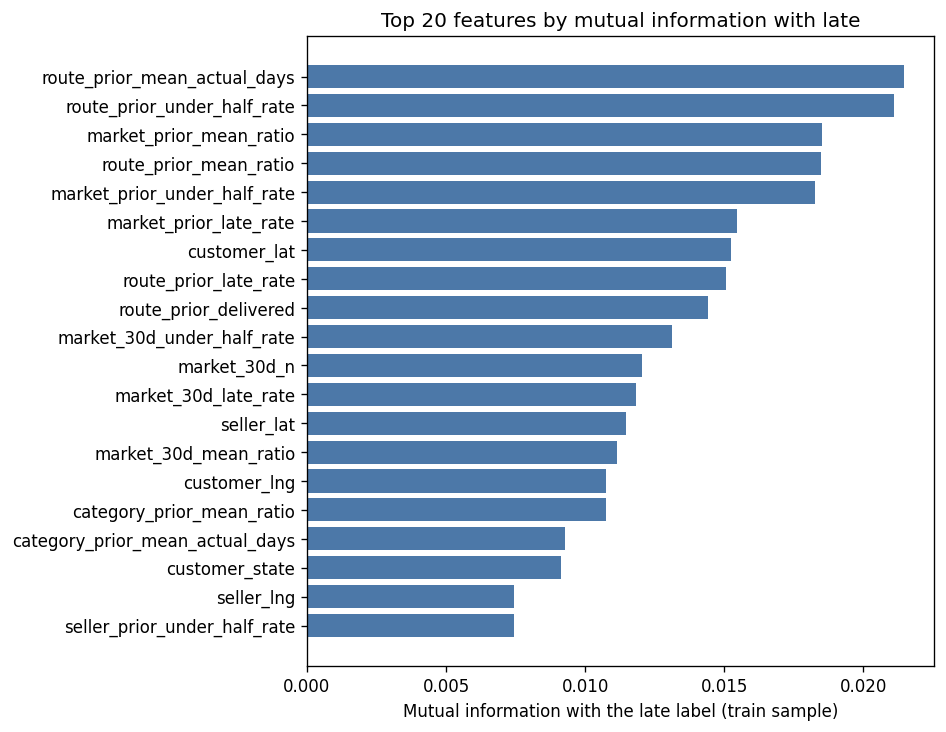

In [13]:
cat_cols = [col for col in surviving if col in CAT_COLS]
num_cols = [col for col in surviving if col not in cat_cols]


def encoded_frame(frame, cat_maps):
    encoded = pd.DataFrame(index=frame.index)
    for col in num_cols:
        encoded[col] = pd.to_numeric(frame[col], errors="coerce")
    for col in cat_cols:
        encoded[col] = frame[col].map(cat_maps[col])
    return encoded


cat_maps = {}
for col in cat_cols:
    levels = pd.Index(train[col].dropna().astype(str).unique())
    cat_maps[col] = {level: i for i, level in enumerate(levels)}

train_encoded = encoded_frame(train, cat_maps)
y_train = train["y"].to_numpy()
sample_idx, _ = train_test_split(
    np.arange(len(train_encoded)),
    train_size=min(MI_SAMPLE, len(train_encoded)),
    stratify=y_train,
    random_state=RANDOM_STATE,
)
sample = train_encoded.iloc[sample_idx].copy()
y_late = (y_train[sample_idx] == 2).astype(int)

discrete_idx = []
for col in sample.columns:
    if col in cat_cols:
        sample[col] = sample[col].fillna(sample[col].max() + 1 if sample[col].notna().any() else 0)
        discrete_idx.append(True)
    else:
        sample[col] = sample[col].fillna(sample[col].median())
        discrete_idx.append(False)

continuous = [col for col, is_discrete in zip(sample.columns, discrete_idx) if not is_discrete]
scaler = StandardScaler()
sample[continuous] = scaler.fit_transform(sample[continuous])

mi_values = mutual_info_classif(
    sample.to_numpy(dtype=float),
    y_late,
    discrete_features=np.array(discrete_idx),
    n_neighbors=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
mi = pd.Series(mi_values, index=sample.columns, name="mutual_info")
mi_table = mi.sort_values(ascending=False).rename("mutual_info").reset_index().rename(columns={"index": "feature"})
mi_table = mi_table.merge(dictionary[["feature", "group"]], on="feature", how="left")
print(mi_table.head(20).round(4).to_string(index=False))
mi_table.to_csv(OUT / "feature_mutual_info.csv", index=False)

top = mi_table.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6.2))
ax.barh(top["feature"], top["mutual_info"], color="#4C78A8")
ax.set_xlabel("Mutual information with the late label (train sample)")
ax.set_title("Top 20 features by mutual information with late")
fig.tight_layout()
fig.savefig(FIG / "feature_mutual_info_top20.png", dpi=140)
plt.show()


### 7. Correlation filter

Spearman correlation is computed on train. Among numeric columns, a pair at or above 0.92 keeps the column with higher mutual information with the late label. Categorical columns are not part of this filter.


In [15]:
corr = train[num_cols].apply(pd.to_numeric, errors="coerce").corr(method="spearman").abs()
ordered = sorted(num_cols, key=lambda col: mi.get(col, 0.0), reverse=True)
kept_num = []
dropped_pairs = []
for col in ordered:
    if not kept_num:
        kept_num.append(col)
        continue
    correlations = corr.loc[col, kept_num]
    partner = correlations.idxmax()
    rho = float(correlations.max())
    if np.isnan(rho) or rho < CORR_THRESHOLD:
        kept_num.append(col)
    else:
        dropped_pairs.append({
            "dropped": col,
            "kept_instead": partner,
            "abs_spearman": round(rho, 3),
            "mi_dropped": round(float(mi.get(col, 0.0)), 4),
            "mi_kept": round(float(mi.get(partner, 0.0)), 4),
        })

pair_table = pd.DataFrame(dropped_pairs)
print(f"numeric columns kept: {len(kept_num)} of {len(num_cols)}")
print(f"categorical columns kept through this step: {len(cat_cols)}")
if pair_table.empty:
    print("no pairs above the threshold")
else:
    print(pair_table.sort_values("abs_spearman", ascending=False).to_string(index=False))
    pair_table.to_csv(OUT / "feature_dropped_correlated_pairs.csv", index=False)

model_features = cat_cols + kept_num
print("columns entering the tree:", len(model_features))


numeric columns kept: 50 of 64
categorical columns kept through this step: 5
                       dropped                kept_instead  abs_spearman  mi_dropped  mi_kept
                     price_max                  price_mean         0.999      0.0027   0.0041
  market_prior_under_half_rate     market_prior_mean_ratio         0.995      0.0183   0.0185
   sellers_max_prior_late_rate      seller_prior_late_rate         0.995      0.0022   0.0026
        seller_prior_delivered         seller_prior_orders         0.992      0.0000   0.0013
                  weight_g_max                weight_g_sum         0.983      0.0016   0.0036
                volume_cm3_sum              volume_cm3_max         0.982      0.0034   0.0052
        route_prior_mean_ratio route_prior_under_half_rate         0.966      0.0185   0.0211
category_prior_under_half_rate   category_prior_mean_ratio         0.963      0.0047   0.0107
                     price_sum                  price_mean         0.954     

### 8. Permutation importance on validation

`HistGradientBoostingClassifier` keeps missing history as missing and accepts class weights. The fit uses train only. Each validation column is shuffled five times. Importance is the drop in average precision of the predicted probability of `late`.

Green bars are the stable core: mean drop greater than the standard deviation across the five shuffles. That flag is a stability label. The next section decides how far the ranking can be cut.


In [17]:
def design_matrix(frame, features, cat_maps):
    columns = []
    names = []
    for feature in features:
        if feature in cat_maps:
            codes = frame[feature].astype(str).map(cat_maps[feature]).to_numpy(dtype=float)
            columns.append(codes.reshape(-1, 1))
        else:
            columns.append(pd.to_numeric(frame[feature], errors="coerce").to_numpy(dtype=float).reshape(-1, 1))
        names.append(feature)
    matrix = np.hstack(columns)
    categorical = np.array([feature in cat_maps for feature in names])
    return matrix, names, categorical


def late_scores(model, matrix):
    proba = model.predict_proba(matrix)
    late_col = list(model.classes_).index(2)
    return proba[:, late_col]


def late_average_precision(estimator, x_matrix, y_true):
    return average_precision_score(np.asarray(y_true) == 2, late_scores(estimator, x_matrix))


def fit_model(features):
    maps = {}
    for feature in features:
        if feature in CAT_COLS:
            levels = pd.Index(train[feature].dropna().astype(str).unique())
            maps[feature] = {level: i for i, level in enumerate(levels)}
    x_train, names, categorical = design_matrix(train, features, maps)
    model = HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=31,
        min_samples_leaf=40,
        l2_regularization=0.1,
        class_weight="balanced",
        categorical_features=categorical if categorical.any() else None,
        random_state=RANDOM_STATE,
        early_stopping=False,
    )
    model.fit(x_train, train["y"].to_numpy())
    return model, maps, names


def score_predictions(y_true, y_pred, late_score):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "macro_f1": f1_score(y_true, y_pred, average="macro", labels=[0, 1, 2]),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", labels=[0, 1, 2]),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "quadratic_kappa": cohen_kappa_score(y_true, y_pred, labels=[0, 1, 2], weights="quadratic"),
        "late_f1": f1_score(y_true == 2, y_pred == 2, zero_division=0),
        "late_ap": float(average_precision_score(y_true == 2, late_score)),
    }


full_model, full_maps, full_names = fit_model(model_features)
x_val, _, _ = design_matrix(val, model_features, full_maps)
perm = permutation_importance(
    full_model,
    x_val,
    val["y"].to_numpy(),
    scoring=late_average_precision,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance = pd.DataFrame({
    "feature": full_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
})
importance = importance.merge(dictionary[["feature", "group", "description"]], on="feature", how="left")
importance = importance.merge(mi.rename("mutual_info"), left_on="feature", right_index=True, how="left")
importance["stable_core"] = importance["importance_mean"].gt(importance["importance_std"])
importance = importance.sort_values(["importance_mean", "mutual_info"], ascending=[False, False])
print(importance[["feature", "group", "importance_mean", "importance_std", "stable_core"]].round(4).to_string(index=False))
importance.to_csv(OUT / "feature_permutation_importance.csv", index=False)
print()
print(f"stable core: {int(importance['stable_core'].sum())} of {len(model_features)} tree inputs")


                        feature            group  importance_mean  importance_std  stable_core
                  promised_days            quote           0.0520          0.0017         True
    route_prior_under_half_rate    route_history           0.0259          0.0009         True
                    distance_km            route           0.0124          0.0007         True
   route_prior_mean_actual_days    route_history           0.0111          0.0006         True
                 customer_state            route           0.0079          0.0016         True
                   freight_mean           basket           0.0049          0.0004         True
                   customer_lat            route           0.0042          0.0006         True
           market_30d_late_rate   market_history           0.0035          0.0006         True
  seller_prior_mean_actual_days   seller_history           0.0033          0.0004         True
                   customer_lng            route  

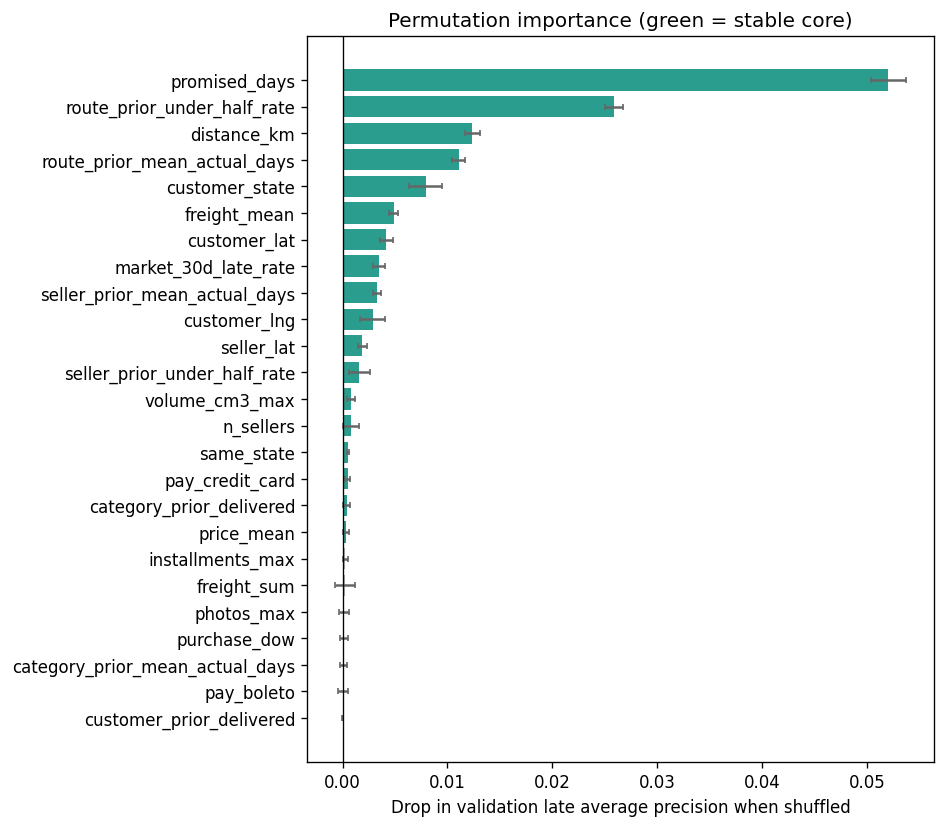

In [18]:
plot_df = importance.head(25).iloc[::-1]
colors = ["#2A9D8F" if flag else "#B0B0B0" for flag in plot_df["stable_core"]]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"],
    color=colors,
    ecolor="#666666",
    capsize=2,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Drop in validation late average precision when shuffled")
ax.set_title("Permutation importance (green = stable core)")
fig.tight_layout()
fig.savefig(FIG / "feature_permutation_importance.png", dpi=140)
plt.show()


### 9. Choose the prefix on validation

The majority-class row reports late average precision equal to the late prevalence, which is the ranking baseline for a constant score. Prefixes are taken in permutation-importance order. The grid is 10, 16, 24, 36, and the full correlation-filtered set. The modelling set is the shortest prefix whose validation late average precision is within 0.01 of the best prefix on that grid. The mechanical-filter row is a reference. It is not on the grid.


            feature_set  n_features split  macro_f1  weighted_f1   mcc  quadratic_kappa  late_f1  late_ap
         majority_class           0 train     0.237        0.393 0.000            0.000    0.000    0.080
         majority_class           0   val     0.276        0.584 0.000            0.000    0.000    0.054
after_mechanical_filter          69 train     0.720        0.757 0.578            0.641    0.650    0.747
after_mechanical_filter          69   val     0.341        0.633 0.154            0.146    0.000    0.125
   top_10_by_importance          10 train     0.631        0.684 0.456            0.535    0.531    0.556
   top_10_by_importance          10   val     0.413        0.617 0.140            0.240    0.176    0.131
   top_16_by_importance          16 train     0.657        0.705 0.491            0.568    0.567    0.604
   top_16_by_importance          16   val     0.404        0.614 0.135            0.224    0.148    0.124
   top_24_by_importance          24 train     

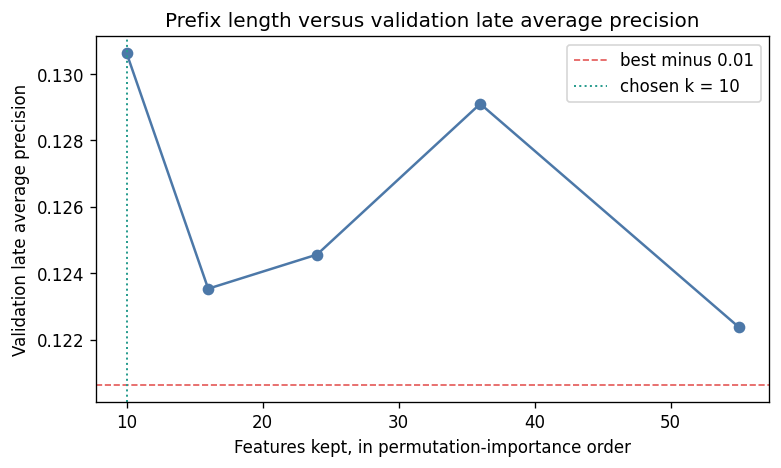

In [20]:
def evaluate_feature_set(name, features, splits):
    model, maps, _ = fit_model(features)
    rows = []
    for split_name, frame in splits:
        matrix, _, _ = design_matrix(frame, features, maps)
        pred = model.predict(matrix)
        rows.append({
            "feature_set": name,
            "n_features": len(features),
            "split": split_name,
            **score_predictions(frame["y"], pred, late_scores(model, matrix)),
        })
    return rows, model, maps


ranking = importance["feature"].tolist()
prefix_sizes = [k for k in (10, 16, 24, 36) if k < len(ranking)]
prefix_sizes.append(len(ranking))

metric_rows = []
for split_name, frame in [("train", train), ("val", val)]:
    prevalence = float(frame["y"].eq(2).mean())
    pred = np.zeros(len(frame), dtype=int)
    metric_rows.append({
        "feature_set": "majority_class",
        "n_features": 0,
        "split": split_name,
        **score_predictions(frame["y"], pred, np.full(len(frame), prevalence)),
    })

mech_rows, _, _ = evaluate_feature_set(
    "after_mechanical_filter", surviving, [("train", train), ("val", val)]
)
metric_rows.extend(mech_rows)

fitted_by_k = {}
for k in prefix_sizes:
    rows, model, maps = evaluate_feature_set(
        f"top_{k}_by_importance", ranking[:k], [("train", train), ("val", val)]
    )
    metric_rows.extend(rows)
    fitted_by_k[k] = (model, maps, ranking[:k])

metrics = pd.DataFrame(metric_rows)
print(metrics.round(3).to_string(index=False))
metrics.to_csv(OUT / "feature_selection_val_metrics.csv", index=False)

val_curve = (
    metrics.loc[metrics["split"].eq("val") & metrics["feature_set"].str.startswith("top_")]
    .sort_values("n_features")
)
best_ap = float(val_curve["late_ap"].max())
eligible = val_curve.loc[val_curve["late_ap"] >= best_ap - AP_TOLERANCE]
chosen_k = int(eligible["n_features"].min())
selected_model, selected_maps, selected_features = fitted_by_k[chosen_k]
print()
print(f"best validation late average precision on the grid: {best_ap:.3f}")
print(f"shortest prefix within {AP_TOLERANCE:.2f}: {chosen_k} features")

val_matrix, _, _ = design_matrix(val, selected_features, selected_maps)
val_pred = selected_model.predict(val_matrix)
print()
print(classification_report(val["y"], val_pred, target_names=BANDS, digits=3))

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(val_curve["n_features"], val_curve["late_ap"], marker="o", color="#4C78A8")
ax.axhline(best_ap - AP_TOLERANCE, color="#E45756", linestyle="--", linewidth=1, label="best minus 0.01")
ax.axvline(chosen_k, color="#2A9D8F", linestyle=":", linewidth=1.2, label=f"chosen k = {chosen_k}")
ax.set_xlabel("Features kept, in permutation-importance order")
ax.set_ylabel("Validation late average precision")
ax.set_title("Prefix length versus validation late average precision")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "feature_selection_curve.png", dpi=140)
plt.show()


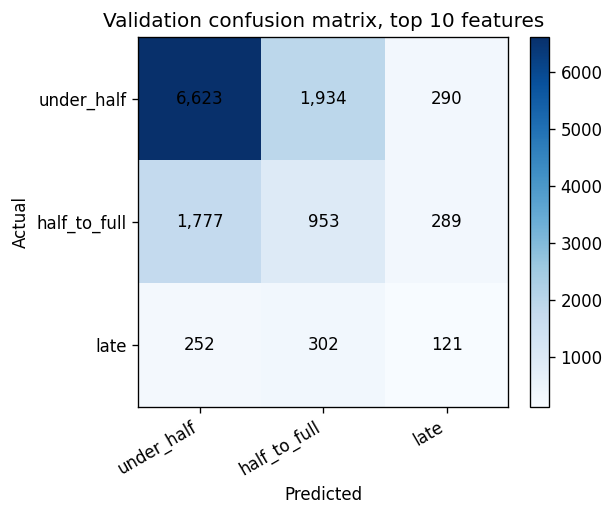

In [21]:
matrix = confusion_matrix(val["y"], val_pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(5.2, 4.4))
image = ax.imshow(matrix, cmap="Blues")
ax.set_xticks([0, 1, 2], BANDS, rotation=30, ha="right")
ax.set_yticks([0, 1, 2], BANDS)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Validation confusion matrix, top {len(selected_features)} features")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{matrix[i, j]:,}", ha="center", va="center", color="black")
fig.colorbar(image, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIG / "promise_band_val_confusion.png", dpi=140)
plt.show()


### 10. Frozen test check

This cell does not change the feature set. The prefix was chosen on validation. The model was fit on train. Test only checks the same columns on later orders.


In [23]:
test_matrix, _, _ = design_matrix(test, selected_features, selected_maps)
test_pred = selected_model.predict(test_matrix)
test_scores = score_predictions(test["y"], test_pred, late_scores(selected_model, test_matrix))
test_row = pd.DataFrame([{
    "feature_set": f"top_{len(selected_features)}_by_importance",
    "n_features": len(selected_features),
    "split": "test",
    **test_scores,
}])
print(test_row.round(3).to_string(index=False))
print()
print(classification_report(test["y"], test_pred, target_names=BANDS, digits=3))
test_prevalence = float(test["y"].eq(2).mean())
print(f"test late share: {100 * test_prevalence:.1f}%")
print(f"test late average precision: {test_scores['late_ap']:.3f}")
print(f"test late average precision minus prevalence: {test_scores['late_ap'] - test_prevalence:.3f}")

final = importance.set_index("feature").loc[selected_features].reset_index()
final.insert(0, "rank", range(1, len(final) + 1))
final.to_csv(OUT / "selected_features.csv", index=False)
print()
print("modelling features, in importance order:")
print(final[["rank", "feature", "group", "importance_mean", "stable_core"]].round(4).to_string(index=False))

watched = [
    "promised_days",
    "route_prior_late_rate",
    "category_prior_late_rate",
    "seller_prior_late_rate_30d",
    "seller_prior_late_rate",
    "freight_to_price",
    "same_state",
    "market_30d_late_rate",
]
rank = {feature: i + 1 for i, feature in enumerate(ranking)}
watched_table = importance.set_index("feature").reindex(watched).reset_index()
watched_table.insert(0, "rank", [rank.get(feature) for feature in watched_table["feature"]])
print()
print("columns named for a second look:")
print(watched_table[["rank", "feature", "importance_mean", "stable_core"]].round(4).to_string(index=False))
print("customer-history columns dropped before the tree:", [col for col in dropped_mechanical if col.startswith("customer_")])


         feature_set  n_features split  macro_f1  weighted_f1   mcc  quadratic_kappa  late_f1  late_ap
top_10_by_importance          10  test     0.342        0.444 0.051             0.05    0.128     0.07

              precision    recall  f1-score   support

  under_half      0.645     0.415     0.505      8789
half_to_full      0.352     0.443     0.393      4725
        late      0.085     0.256     0.128       957

    accuracy                          0.414     14471
   macro avg      0.361     0.371     0.342     14471
weighted avg      0.513     0.414     0.444     14471

test late share: 6.6%
test late average precision: 0.070
test late average precision minus prevalence: 0.004

modelling features, in importance order:
 rank                       feature          group  importance_mean  stable_core
    1                 promised_days          quote           0.0520         True
    2   route_prior_under_half_rate  route_history           0.0259         True
    3             

### 11. Sixteen-feature prefix

`selected_features.csv` is the prefix chosen in section 9. On this run that is 10 features, and section 10 scores it on test. The 16-feature prefix of the same importance ranking is written with the same columns to `selected_features_late.csv`. The cell uses the model already fit on train for that prefix in the validation grid, then scores test once. It does not replace the chosen prefix.


In [25]:
late_k = 16
assert late_k in fitted_by_k
late_model, late_maps, late_features = fitted_by_k[late_k]

late_test_matrix, _, _ = design_matrix(test, late_features, late_maps)
late_test_pred = late_model.predict(late_test_matrix)
late_test_scores = score_predictions(
    test["y"], late_test_pred, late_scores(late_model, late_test_matrix)
)
late_test_row = pd.DataFrame([{
    "feature_set": f"top_{late_k}_by_importance",
    "n_features": late_k,
    "split": "test",
    **late_test_scores,
}])
print(late_test_row.round(3).to_string(index=False))
print()
print(classification_report(test["y"], late_test_pred, target_names=BANDS, digits=3))
print(f"test late share: {100 * test_prevalence:.1f}%")
print(f"test late average precision: {late_test_scores['late_ap']:.3f}")
print(
    "test late average precision minus prevalence: "
    f"{late_test_scores['late_ap'] - test_prevalence:.3f}"
)

selected_features_late = importance.set_index("feature").loc[late_features].reset_index()
selected_features_late.insert(0, "rank", range(1, len(selected_features_late) + 1))
late_path = OUT / "selected_features_late.csv"
selected_features_late.to_csv(late_path, index=False)
print()
print(f"wrote {late_path}")
print(
    selected_features_late[
        ["rank", "feature", "group", "importance_mean", "stable_core"]
    ].round(4).to_string(index=False)
)


         feature_set  n_features split  macro_f1  weighted_f1   mcc  quadratic_kappa  late_f1  late_ap
top_16_by_importance          16  test     0.351        0.459 0.079            0.078    0.118    0.072

              precision    recall  f1-score   support

  under_half      0.677     0.424     0.521      8789
half_to_full      0.366     0.472     0.412      4725
        late      0.079     0.236     0.118       957

    accuracy                          0.427     14471
   macro avg      0.374     0.377     0.351     14471
weighted avg      0.536     0.427     0.459     14471

test late share: 6.6%
test late average precision: 0.072
test late average precision minus prevalence: 0.006

wrote /Users/Ailurophile/Documents/IT5006/Project/data/processed/selected_features_late.csv
 rank                       feature          group  importance_mean  stable_core
    1                 promised_days          quote           0.0520         True
    2   route_prior_under_half_rate  route_histo

## How to read the result

Section 9 keeps the shortest prefix whose validation late average precision is within 0.01 of the best prefix on this grid. That file is `selected_features.csv`. On this run it has 10 features. Section 10 scores it once on test.

`selected_features_late.csv` is the 16-feature prefix of the same ranking. Section 11 writes it in the same columns and scores it once on test. It does not replace the chosen prefix: 16 features score 0.124 on validation late average precision, 0.007 below the best value of 0.131, and the rule keeps the shortest prefix inside the band. The stable-core flag does not choose the set.

`promised_days` is the length of the quote the customer was shown. It belongs in a promise-setting model. It is not the delivery scan. Direct late-rate columns can rank below route speed, distance, and the quote once those are present. Their ranks are in the last table of section 10. Customer-level rates are dropped before the tree when more than 95% of train orders have no completed prior delivery.

Train scores are higher than validation scores. The comparison uses validation. Test is reported once for each saved prefix. If test late average precision is not above the test late share, the ranking did not carry to the later window.

Fields that stay out of the feature list: the delivery timestamp, the duration ratio, carrier handoff, approval time, the seller shipping deadline, reviews, and the raw purchase timestamp.
